In [ ]:
#pip install kaggle
#JOIN COMPETITION TO allow download dataset
#import os
#os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
#!mv ~/Downloads/kaggle.json ~/.kaggle/
#!chmod 600 ~/.kaggle/kaggle.json
#!kaggle competitions download -c stanford-rna-3d-folding
#!unzip stanford-rna-3d-folding.zip -d data/
#!rm stanford-rna-3d-folding.zip

In [94]:
## make a new data file
import pandas as pd
import numpy as np

# Load the CSV file
df = pd.read_csv('./data/train_labels.csv')

# Extract mol_id and residue index
df['mol_base'] = df['ID'].apply(lambda x: '_'.join(x.split('_')[:2]))
df['res_index'] = df['ID'].apply(lambda x: int(x.split('_')[-1]))

# Initialize output list
output_rows = []
global_mol_id = 1  # Global molecule ID counter

for mol_base, group in df.groupby('mol_base'):
    group = group.sort_values('resid').reset_index(drop=True)

    current_segment = []
    prev_resid = None

    for _, row in group.iterrows():
        missing_coords = pd.isna(row['x_1']) or pd.isna(row['y_1']) or pd.isna(row['z_1'])
        resid_break = (prev_resid is not None and row['resid'] != prev_resid + 1)

        # If residue breaks or coords are missing, save current segment and reset
        if (resid_break or missing_coords) and current_segment:
            for r in current_segment:
                r['mol_name'] = mol_base
                r['mol_id'] = global_mol_id
                output_rows.append(r)
            global_mol_id += 1
            current_segment = []

        if not missing_coords:
            current_segment.append(row.to_dict())

        prev_resid = row['resid']

    # Save last segment
    if current_segment:
        for r in current_segment:
            r['mol_name'] = mol_base
            r['mol_id'] = global_mol_id
            output_rows.append(r)
        global_mol_id += 1

final_df = pd.DataFrame(output_rows)
final_df = final_df[['mol_name', 'mol_id', 'resname', 'resid', 'x_1', 'y_1', 'z_1']]

# Save to CSV
final_df.to_csv('RNA_data.csv', index=False)


In [51]:
## bond calculation
import pandas as pd
import numpy as np

# Load the CSV file
df = pd.read_csv('./data/train_labels.csv')

# Extract molecule ID by removing the last underscore and number
df['mol_id'] = df['ID'].apply(lambda x: '_'.join(x.split('_')[:-1]))

# Prepare a list to collect results
results = []

# Group by molecule
for mol_id, group in df.groupby('mol_id'):
    group = group.sort_values(by='resid').reset_index(drop=True)

    # Iterate through rows manually to check adjacency
    for i in range(len(group) - 1):
        row1 = group.iloc[i]
        row2 = group.iloc[i + 1]

        # Only compute vector if resid is adjacent and no missing coords
        if row2['resid'] == row1['resid'] + 1:
            if not (pd.isna(row1[['x_1', 'y_1', 'z_1']]).any() or pd.isna(row2[['x_1', 'y_1', 'z_1']]).any()):
                vx = row2['x_1'] - row1['x_1']
                vy = row2['y_1'] - row1['y_1']
                vz = row2['z_1'] - row1['z_1']
                bond = np.sqrt(vx**2 + vy**2 + vz**2)

                results.append({
                    'mol_id': mol_id,
                    'ID': row1['ID'],
                    'resid1': row1['resid'],
                    'resid2': row2['resid'],
                    'res_1': row1['resname'],
                    'res_2': row2['resname'],
                    'vx': vx,
                    'vy': vy,
                    'vz': vz,
                    'bond': bond
                })

# Combine all molecules' results
#final_df = pd.concat(results, ignore_index=True)
vector_df = pd.DataFrame(results)

# View a few results
print(vector_df[['mol_id', 'ID', 'resid1','resid2', 'res_1','res_2', 'vx', 'vy', 'vz','bond']].head())
# Save to a text file
vector_df[['mol_id', 'resid1','resid2','res_1','res_2','vx', 'vy', 'vz','bond']].to_csv(
    'train_label_bonds.txt', 
    index=False, 
    sep='\t'  # Tab-separated for readability
)

   mol_id        ID  resid1  resid2 res_1 res_2        vx     vy     vz  \
0  17RA_A  17RA_A_1       1       2     G     G -5.626999 -1.306 -1.066   
1  17RA_A  17RA_A_2       2       3     G     C -6.261999  0.719  0.924   
2  17RA_A  17RA_A_3       3       4     C     G -4.672001  1.482  2.912   
3  17RA_A  17RA_A_4       4       5     G     U -2.934000  3.827  4.072   
4  17RA_A  17RA_A_5       5       6     U     A -0.726000  4.498  3.169   

       bond  
0  5.874105  
1  6.370508  
2  5.701198  
3  6.311534  
4  5.549923  


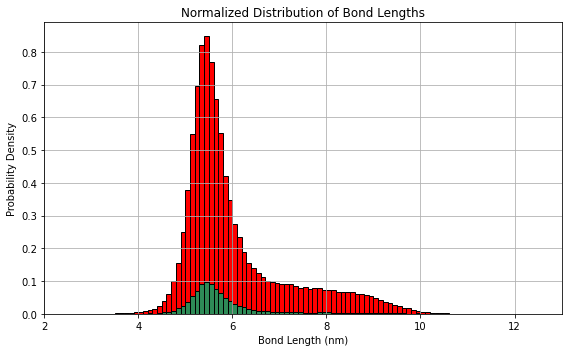

In [72]:
import matplotlib.pyplot as plt

# Assume bond length is stored in a column named 'bond_length'
# Replace with actual column name if different
bond_lengths = vector_df['bond'].dropna()

bins = np.linspace(2.5, 12.5, 101)

gg_bonds = vector_df[(vector_df['res_1'] == 'G') & (vector_df['res_2'] == 'G')]
gg_lengths = gg_bonds['bond'].dropna()

ag_bonds = vector_df[
    ((vector_df['res_1'] == 'A') & (vector_df['res_2'] == 'G')) |
    ((vector_df['res_1'] == 'G') & (vector_df['res_2'] == 'A'))
]
ag_lengths = ag_bonds['bond'].dropna()

cg_bonds = vector_df[
    ((vector_df['res_1'] == 'C') & (vector_df['res_2'] == 'G')) |
    ((vector_df['res_1'] == 'G') & (vector_df['res_2'] == 'C'))
]
cg_lengths = cg_bonds['bond'].dropna()

lengths = gg_lengths
# Calculate histogram manually with density=True
hist, bin_edges = np.histogram(lengths, bins=bins, density=True)
scaled = hist * len(lengths)/len(bond_lengths)

# Plot
plt.figure(figsize=(8, 5))
plt.hist(bond_lengths, bins=bins, density=True, color='red', edgecolor='black')
plt.bar(bin_edges[:-1], scaled, width=np.diff(bin_edges), align='edge',
        color='seagreen', edgecolor='black')

# Add labels and title
plt.xlabel('Bond Length (nm)')
plt.ylabel('Probability Density')
plt.title('Normalized Distribution of Bond Lengths')
plt.grid(True)
plt.tight_layout()

plt.show()


/var/folders/h0/fh3ps4592l92zlj4lhkwz7x40000gn/T/ipykernel_60422/742181381.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bond_df['bond_type'] = bond_df.apply(lambda row: '-'.join(sorted([row['res_1'], row['res_2']])), axis=1)


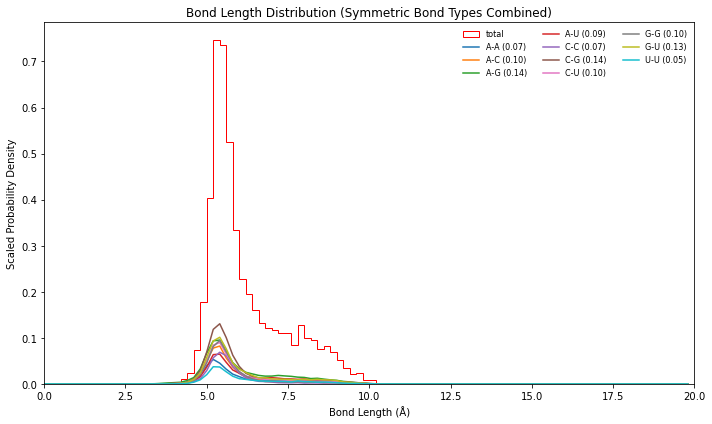

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# Load bond data
bond_df = vector_df

# Ensure only valid residues are included
valid_bases = {'A', 'U', 'C', 'G'}
bond_df = bond_df[bond_df['res_1'].isin(valid_bases) & bond_df['res_2'].isin(valid_bases)]

# Total number of bonds
total_bonds = len(bond_df)

# Normalize bond types by sorting residues alphabetically
bond_df['bond_type'] = bond_df.apply(lambda row: '-'.join(sorted([row['res_1'], row['res_2']])), axis=1)

# Create bins
bins = np.linspace(0, 20, 101)

# Set up plot
plt.figure(figsize=(10, 6))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

plt.hist(bond_lengths, bins=bins, density=True, histtype='step',color='red',label='total')
# Group and plot
bond_groups = bond_df.groupby('bond_type')
for i, (bond_type, group) in enumerate(bond_groups):
    bond_lengths = group['bond'].dropna()
    count = len(bond_lengths)
    ratio = count / total_bonds

    # Histogram scaled by bond type frequency
    hist, bin_edges = np.histogram(bond_lengths, bins=bins, density=True)
    hist_scaled = hist * ratio

    plt.plot(bin_edges[:-1], hist_scaled, label=f'{bond_type} ({ratio:.2f})', color=colors[i % len(colors)])

# Plot formatting
plt.xlim(0, 20)
plt.xlabel('Bond Length (Å)')
plt.ylabel('Scaled Probability Density')
plt.title('Bond Length Distribution (Symmetric Bond Types Combined)')
plt.legend(ncol=3, fontsize=8, frameon=False)
#plt.grid(True)
plt.tight_layout()
plt.show()


In [73]:
### angles 

import pandas as pd
import numpy as np

bond_df = pd.read_csv('train_label_bonds.txt', sep='\t')

angle_results = []

for mol_id, group in bond_df.groupby('mol_id'):
    group = group.reset_index(drop=True)

    for i in range(len(group) - 1):
        row1 = group.loc[i]
        row2 = group.loc[i + 1]

        # Ensure the vectors are connected
        if row1['resid2'] != row2['resid1']:
            continue

        v1 = row1[['vx', 'vy', 'vz']].values
        v2 = row2[['vx', 'vy', 'vz']].values

        norm_v1 = np.linalg.norm(v1)
        norm_v2 = np.linalg.norm(v2)

        if norm_v1 == 0 or norm_v2 == 0:
            continue

        cos_theta = np.clip(np.dot(v1, v2) / (norm_v1 * norm_v2), -1.0, 1.0)
        angle_deg = np.degrees(np.arccos(cos_theta))

        angle_results.append({
            'mol_id': mol_id,
            'resid1': row1['resid1'],
            'resid2': row1['resid2'],
            'resid3': row2['resid2'],
            'res_1': row1['res_1'],
            'res_2': row1['res_2'],
            'res_3': row2['res_2'],
            'angle_deg': angle_deg
        })

# Convert to DataFrame and save
angle_df = pd.DataFrame(angle_results)
angle_df.to_csv('train_label_angles.txt', sep='\t', index=False)


/var/folders/h0/fh3ps4592l92zlj4lhkwz7x40000gn/T/ipykernel_60422/336550081.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ggg_angles = angle_df[(vector_df['res_1'] == 'G') & (angle_df['res_2'] == 'G')& (angle_df['res_3'] == 'G')]


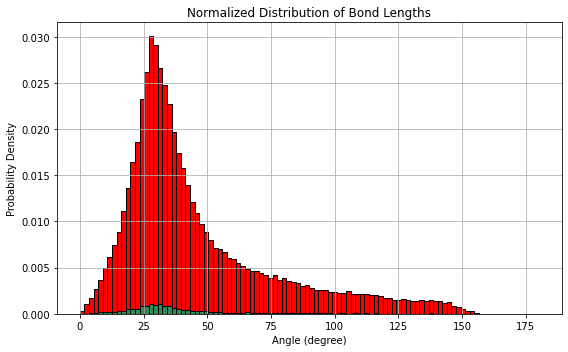

In [ ]:
import matplotlib.pyplot as plt

# Assume bond length is stored in a column named 'bond_length'
# Replace with actual column name if different
angle_size = angle_df['angle_deg'].dropna()

bins = np.linspace(0, 180, 101)

ggg_angles = angle_df[(vector_df['res_1'] == 'G') & (angle_df['res_2'] == 'G')& (angle_df['res_3'] == 'G')]
ggg_a = ggg_angles['angle_deg'].dropna()

angles = ggg_a
# Calculate histogram manually with density=True
hist, bin_edges = np.histogram(angles, bins=bins, density=True)
scaled = hist * len(angles)/len(angle_size)

# Plot
plt.figure(figsize=(8, 5))
plt.hist(angle_size, bins=bins, density=True, color='red', edgecolor='black')
plt.bar(bin_edges[:-1], scaled, width=np.diff(bin_edges), align='edge',
        color='seagreen', edgecolor='black')

# Add labels and title
plt.xlabel('Angle (degree)')
plt.ylabel('Probability Density')
plt.title('Normalized Distribution of Angles')
plt.grid(True)
plt.tight_layout()

plt.show()


In [77]:
### torsion dihedral angles

import pandas as pd
import numpy as np

bond_df = pd.read_csv('train_label_bonds.txt', sep='\t')

torsion_results = []

for mol_id, group in bond_df.groupby('mol_id'):
    group = group.reset_index(drop=True)

    for i in range(len(group) - 2):
        row1 = group.loc[i]
        row2 = group.loc[i + 1]
        row3 = group.loc[i + 2]

        # Ensure vectors are connected: res1-res2, res2-res3, res3-res4
        if row1['resid2'] != row2['resid1'] or row2['resid2'] != row3['resid1']:
            continue

        v1 = row1[['vx', 'vy', 'vz']].astype(float).values
        v2 = row2[['vx', 'vy', 'vz']].astype(float).values
        v3 = row3[['vx', 'vy', 'vz']].astype(float).values

        # Compute normals to planes
        n1 = np.cross(v1, v2)
        n2 = np.cross(v2, v3)

        # Normalize v2
        v2_unit = v2 / np.linalg.norm(v2)
        m1 = np.cross(n1, v2_unit)

        x = np.dot(n1, n2)
        y = np.dot(m1, n2)

        angle_rad = np.arctan2(y, x)
        angle_deg = np.degrees(angle_rad)

        torsion_results.append({
            'mol_id': mol_id,
            'resid1': row1['resid1'],
            'resid2': row1['resid2'],
            'resid3': row2['resid2'],
            'resid4': row3['resid2'],
            'res_1': row1['res_1'],
            'res_2': row1['res_2'],
            'res_3': row2['res_2'],
            'res_4': row3['res_2'],
            'torsion_deg': angle_deg
        })

# Save to file
torsion_df = pd.DataFrame(torsion_results)
torsion_df.to_csv('train_label_torsions.txt', sep='\t', index=False)


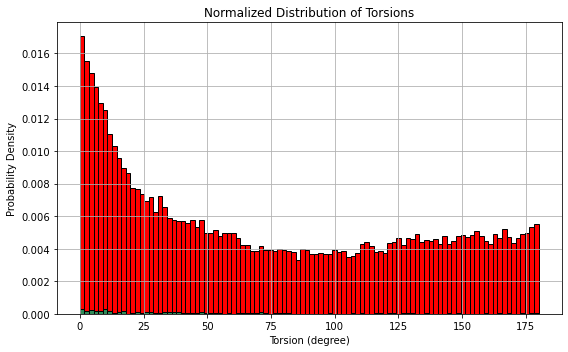

In [80]:
import matplotlib.pyplot as plt

# Assume bond length is stored in a column named 'bond_length'
# Replace with actual column name if different
tors_size = torsion_df['torsion_deg'].dropna()

bins = np.linspace(0, 180, 101)

gggg_tors = torsion_df[(torsion_df['res_1'] == 'G')&(torsion_df['res_2'] == 'G')&(torsion_df['res_3'] == 'G')&(torsion_df['res_4'] == 'G')]
gggg_t = gggg_tors['torsion_deg'].dropna()

trosions = gggg_t
# Calculate histogram manually with density=True
hist, bin_edges = np.histogram(trosions, bins=bins, density=True)
scaled = hist * len(trosions)/len(tors_size)

# Plot
plt.figure(figsize=(8, 5))
plt.hist(tors_size, bins=bins, density=True, color='red', edgecolor='black')
plt.bar(bin_edges[:-1], scaled, width=np.diff(bin_edges), align='edge',
        color='seagreen', edgecolor='black')

# Add labels and title
plt.xlabel('Torsion (degree)')
plt.ylabel('Probability Density')
plt.title('Normalized Distribution of Torsions')
plt.grid(True)
plt.tight_layout()

plt.show()


Randomly selected molecule: 2NBZ_A 
Random seed:  8138


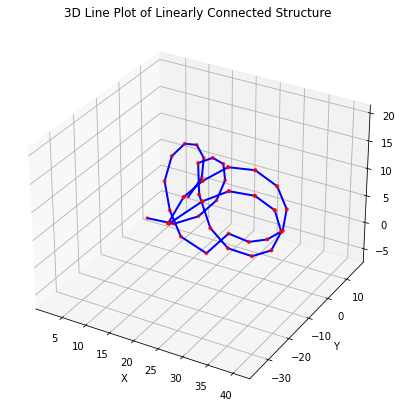

In [7]:
### Plot molecular 3D structures
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Load the CSV file
df = pd.read_csv('./data/train_labels.csv')

df['mol_prefix'] = df['ID'].str.rsplit('_', n=1).str[0]
unique_molecules = df['mol_prefix'].unique()

#np.random.seed(42)  # 42 is just a commonly used example
seed = np.random.randint(0, 100000)
np.random.seed(seed)

selected_mol = np.random.choice(unique_molecules)
print("Randomly selected molecule:", selected_mol, "\nRandom seed: ", seed)
 
# Filter for rows that belong to molecule 1SCL_A
df_1scl = df[df['ID'].str.startswith(selected_mol)]

# Sort by resid if not already sorted
df = df_1scl.sort_values(by='resid')

# Create a 3D line plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the line connecting the points
ax.plot(df['x_1'], df['y_1'], df['z_1'], color='blue', linewidth=2)

# Optionally scatter points on top for clarity
ax.scatter(df['x_1'], df['y_1'], df['z_1'], color='red',s=10)

# Axis labels and title
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Line Plot of Linearly Connected Structure')

plt.show()
